In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, 
    r2_score, mean_absolute_error, mean_squared_error
)

In [2]:
# VERİ SETİNİN YÜKLENMESİ 
dosya_yolu = r"C:\Users\omer\Desktop\arac_fiyat_tahmin_veri_seti_v1.csv"
veri = pd.read_csv(dosya_yolu)

# AYKIRI DEĞERLERİN TEMİZLENMESİ (0.04 - 0.999) 
alt_limit = veri['fiyat'].quantile(0.04)
ust_limit = veri['fiyat'].quantile(0.999)

print(f"Eski Veri Boyutu: {len(veri)}")
veri = veri[(veri['fiyat'] >= alt_limit) & (veri['fiyat'] <= ust_limit)]
print(f"Yeni Veri Boyutu: {len(veri)}")
print(f"Fiyat Aralığı: {alt_limit:,.0f} TL - {ust_limit:,.0f} TL\n")

Eski Veri Boyutu: 50380
Yeni Veri Boyutu: 48386
Fiyat Aralığı: 170,000 TL - 7,043,470 TL



In [3]:
# ÖN İŞLEME 
if 'marka' in veri.columns:
    veri = veri.drop(columns=['marka', 'seri', 'model'])

# Hedef Değişkenler
veri['fiyat_kategorisi'] = pd.qcut(veri['fiyat'], q=4, labels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
X = veri.drop(columns=['fiyat', 'fiyat_kategorisi'])
y_reg = veri['fiyat']
y_cls = veri['fiyat_kategorisi']

In [4]:
# ÖZELLİK ÖLÇEKLENDİRME (Scaling) - DOĞRUSAL MODELLER İÇİN ŞART 
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Veri Bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=42)
_, _, y_train_cls, y_test_cls = train_test_split(X_scaled, y_cls, test_size=0.2, random_state=42)

In [5]:
# 5. REGRESYON ANALİZİ (Linear Regression) 
print("LINEAR REGRESSION PERFORMANSI")
lr_model = LinearRegression()

# 10-Katlı Çapraz Doğrulama
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(lr_model, X_scaled, y_reg, cv=kf, scoring=['r2', 'neg_mean_absolute_error'])

lr_model.fit(X_train, y_train_reg)
y_pred_reg = lr_model.predict(X_test)

print(f"CV R2 Ortalaması: %{cv_results['test_r2'].mean()*100:.2f}")
print(f"Test R2 Skoru: %{r2_score(y_test_reg, y_pred_reg)*100:.2f}")
print(f"Test MAE: {mean_absolute_error(y_test_reg, y_pred_reg):,.2f} TL")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):,.2f} TL\n")

LINEAR REGRESSION PERFORMANSI
CV R2 Ortalaması: %72.78
Test R2 Skoru: %72.14
Test MAE: 186,594.04 TL
Test RMSE: 318,144.88 TL



In [6]:
# INIFLANDIRMA ANALİZİ (Logistic Regression) 
print("LOGISTIC REGRESSION SINIFLANDIRMA PERFORMANSI ")
# Çok sınıflı sınıflandırma için max_iter artırıldı
log_cls = LogisticRegression(max_iter=2000, random_state=42)
log_cls.fit(X_train, y_train_cls)
y_pred_cls = log_cls.predict(X_test)

print(f"Accuracy: %{accuracy_score(y_test_cls, y_pred_cls)*100:.2f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_cls, y_pred_cls))

LOGISTIC REGRESSION SINIFLANDIRMA PERFORMANSI 
Accuracy: %79.02

Sınıflandırma Raporu:
              precision    recall  f1-score   support

       Düşük       0.83      0.83      0.83      2434
        Lüks       0.89      0.88      0.89      2377
        Orta       0.69      0.70      0.70      2412
      Yüksek       0.75      0.75      0.75      2455

    accuracy                           0.79      9678
   macro avg       0.79      0.79      0.79      9678
weighted avg       0.79      0.79      0.79      9678



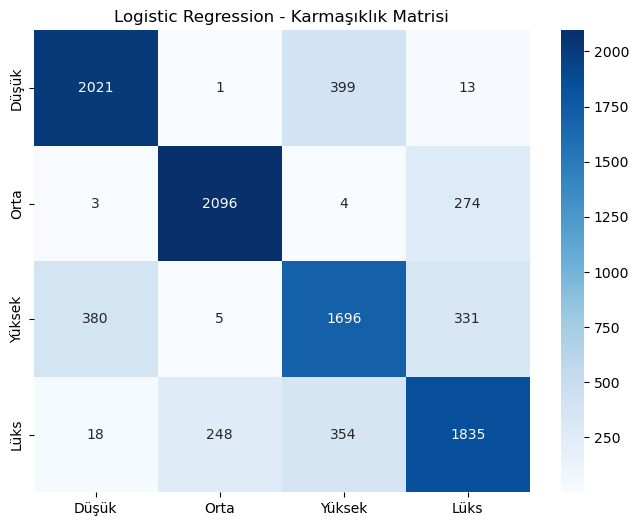

In [7]:
# GÖRSELLEŞTİRMELER 

# Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'],
            yticklabels=['Düşük', 'Orta', 'Yüksek', 'Lüks'])
plt.title('Logistic Regression - Karmaşıklık Matrisi')
plt.show()

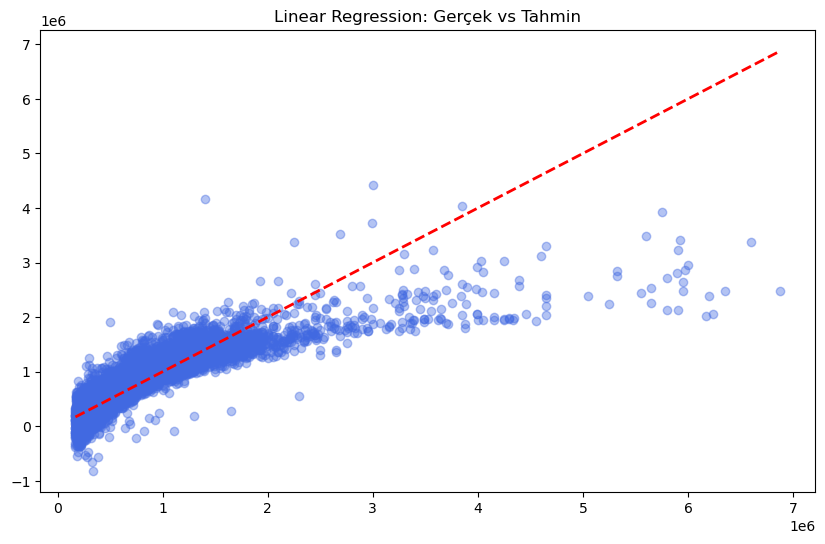

In [8]:
# Gerçek vs Tahmin Grafiği
plt.figure(figsize=(10,6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4, color='royalblue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.title('Linear Regression: Gerçek vs Tahmin')
plt.show()

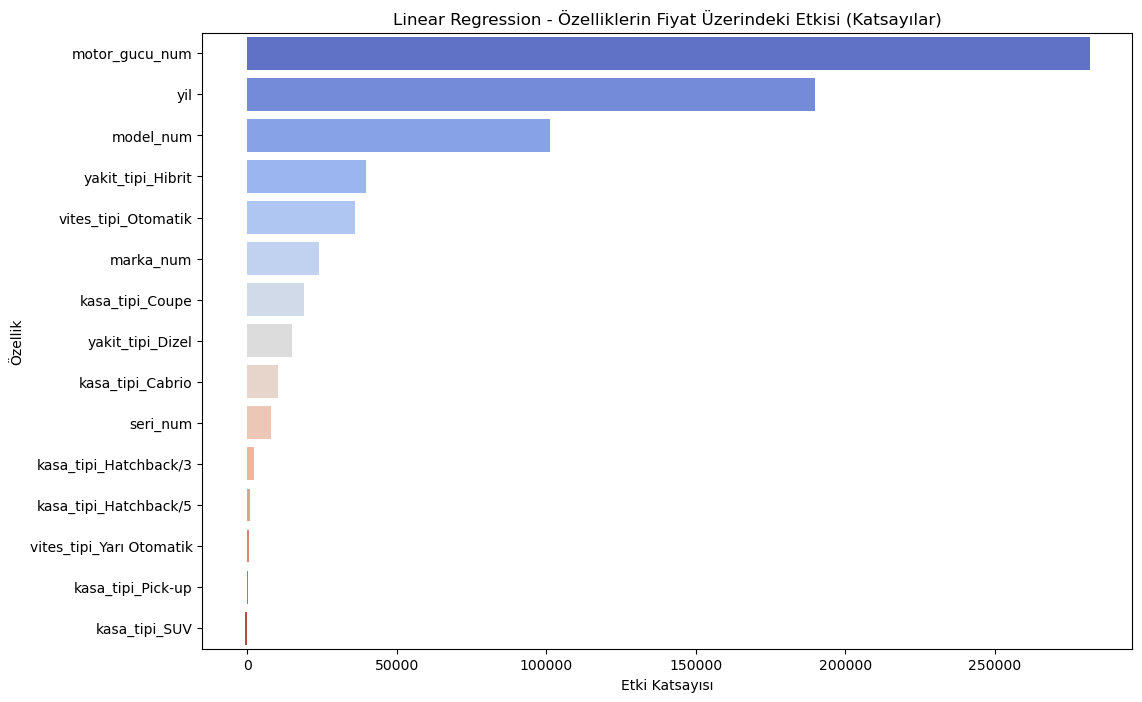

In [9]:
# ÖZELLİK ETKİ ANALİZİ (Katsayılar)
katsayilar = pd.DataFrame({
    'Özellik': X.columns,
    'Etki Katsayısı': lr_model.coef_
}).sort_values(by='Etki Katsayısı', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x="Etki Katsayısı", y="Özellik", data=katsayilar.head(15), palette="coolwarm", hue="Özellik", legend=False)
plt.title('Linear Regression - Özelliklerin Fiyat Üzerindeki Etkisi (Katsayılar)')
plt.show()

In [11]:
# MODEL PAKETLEME VE KAYIT 
model_paketi = {
    'regresyon_modeli': lr_model,
    'siniflandirma_modeli': log_cls,
    'scaler': scaler,
    'egitim_sutunlari': X.columns.tolist(),
    'alt_limit': alt_limit,
    'ust_limit': ust_limit  # <-- Burada 'us_limit' yazıyordu, 'ust_limit' olarak düzelttik
}
joblib.dump(model_paketi, "linear_model.joblib")
print("✅ Linear & Logistic Regression Modeli başarıyla kaydedildi.")

✅ Linear & Logistic Regression Modeli başarıyla kaydedildi.


In [12]:
# ÖRNEK UYGULAMA 
def arac_fiyat_tahmin_lr(paketi, yeni_veri):
    m = paketi['regresyon_modeli']
    s = paketi['scaler']
    cols = paketi['egitim_sutunlari']
    
    df = pd.DataFrame([yeni_veri])
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    df = df[cols]
    df_scaled = s.transform(df)
    return m.predict(df_scaled)[0]

yeni_arac = {
   "yil": 2021,
    "kilometre": 63000,
    "degisen_sayisi": 0,
    "boyali_sayisi": 0,
    "motor_hacmi_num": 1490,
    "motor_gucu_num": 125,
    "marka_num": 50,      # Toyota ID
    "seri_num": 144,      # Corolla ID
    "model_num": 940,     # 1.5 Dream ID
    "vites_tipi_Düz": 0,
    "vites_tipi_Otomatik": 1,
    "vites_tipi_Yarı Otomatik": 0,
    "yakit_tipi_Benzin": 1,
    "yakit_tipi_Dizel": 0,
    "yakit_tipi_Elektrik": 0,
    "yakit_tipi_Hibrit": 0,
    "yakit_tipi_LPG & Benzin": 0,
    "kasa_tipi_Cabrio": 0,
    "kasa_tipi_Coupe": 0,
    "kasa_tipi_Hatchback/3": 0,
    "kasa_tipi_Hatchback/5": 0,
    "kasa_tipi_MPV": 0,
    "kasa_tipi_Pick-up": 0,
    "kasa_tipi_Roadster": 0,
    "kasa_tipi_SUV": 0,
    "kasa_tipi_Sedan": 1,
    "kasa_tipi_Station wagon": 0
}

tahmin_fiyat = arac_fiyat_tahmin_lr(model_paketi, yeni_arac)
print(f"\nGirilen Aracın Tahmini Fiyatı (Linear Reg): {tahmin_fiyat:,.0f} TL")


Girilen Aracın Tahmini Fiyatı (Linear Reg): 1,457,335 TL


C:\Users\omer\anaconda3\envs\usedcar\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
